In [1]:
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op


In [2]:
import scanpy as sc
import numpy as np

In [3]:
adat = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_2/config_easy/net_70_1328_net_60_80_net_135_978/grn_lrp.h5ad')

In [3]:
adat.X

NameError: name 'adat' is not defined

In [14]:
np.argsort(adat.X)

array([[20181, 20365, 20206, ..., 16477, 20283, 20196],
       [20181, 20206, 19916, ..., 17855, 66615, 66724],
       [20221, 55594, 20181, ..., 20341, 56919, 66724],
       ...,
       [66579, 20391, 66586, ..., 21529, 67109, 55449],
       [66579, 66586, 20391, ..., 21096, 65616, 55449],
       [20391, 66586, 20332, ..., 20184, 65515, 65616]],
      shape=(1000, 70225))

In [ ]:
import pandas as pd

In [3]:


def read_all_results(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select):
                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t')
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [56]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three', select=('overlaps_global_top_k.tsv'))
all_overlaps['configuration'] = all_overlaps['method']+'_'+all_overlaps['layer']

/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_70_1328_net_60_80_net_135_978_net_53_1113/overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_70_1328_net_84_59925_net_59_459_net_115_1073/overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_82_144_net_72_516_net_98_1873_net_51_844/overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_60_80_net_64_1212_net_84_1140_net_133_719/overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_60_80_net_90_941_net_75_286_net_77_1396/overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_84_806_net_88_872_net_90_941_net_60_657/overlaps_global_top_k.tsv


In [65]:
all_overlaps['factor'] = all_overlaps['mean_cell_count']/500

In [72]:
all_overlaps.iloc[np.where(all_overlaps['factor']>1.0)]

,Unnamed: 0,n_top,net,avg_edges_recovered,mean_cell_count,gold_standard_edges,max_possible_edges,target,direction,method,net_type,layer,configuration,percentage_overlap,weighted,factor
438,6,0.50,net_70_1328_net_60_80_net_135_978_net_53_1113,88,564.215909,88,101124,on_target,forward,netmap_config_2,strict,X,netmap_config_2_X,1.0,99.302,1.128432
439,7,0.75,net_70_1328_net_60_80_net_135_978_net_53_1113,88,782.954545,88,101124,on_target,forward,netmap_config_2,strict,X,netmap_config_2_X,1.0,137.800,1.565909
440,8,1.00,net_70_1328_net_60_80_net_135_978_net_53_1113,88,1000.000000,88,101124,on_target,forward,netmap_config_2,strict,X,netmap_config_2_X,1.0,176.000,2.000000
447,15,0.50,net_70_1328_net_60_80_net_135_978_net_53_1113,88,517.625000,88,101124,on_target,reverse,netmap_config_2,strict,X,netmap_config_2_X,1.0,91.102,1.035250
448,16,0.75,net_70_1328_net_60_80_net_135_978_net_53_1113,88,693.806818,88,101124,on_target,reverse,netmap_config_2,strict,X,netmap_config_2_X,1.0,122.110,1.387614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3409,7,0.75,net_84_806_net_88_872_net_90_941_net_60_657,92,713.402174,92,103684,on_target,forward,netmap_config_8,unspecific,quantile_count,netmap_config_8_quantile_count,1.0,131.266,1.426804
3410,8,1.00,net_84_806_net_88_872_net_90_941_net_60_657,92,794.000000,92,103684,on_target,forward,netmap_config_8,unspecific,quantile_count,netmap_config_8_quantile_count,1.0,146.096,1.588000
3417,15,0.50,net_84_806_net_88_872_net_90_941_net_60_657,92,527.793478,92,103684,on_target,reverse,netmap_config_8,unspecific,quantile_count,netmap_config_8_quantile_count,1.0,97.114,1.055587
3418,16,0.75,net_84_806_net_88_872_net_90_941_net_60_657,92,749.250000,92,103684,on_target,reverse,netmap_config_8,unspecific,quantile_count,netmap_config_8_quantile_count,1.0,137.862,1.498500


In [ ]:
all_overlaps['weighted'] = all_overlaps['avg_edges_recovered']*(all_overlaps['mean_cell_count']/500)


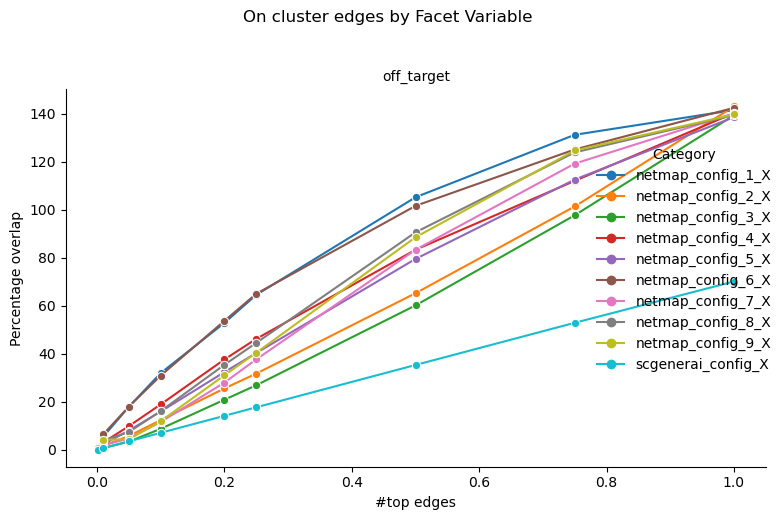

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'all_overlaps' is your DataFrame, and 'new_facet_variable' is the variable you want to use for faceting

# 1. Original data preprocessing (keep this)
all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
all_overlaps = all_overlaps[~all_overlaps.mean_cell_count.isna()]
all_overlaps['percentage_overlap'] = all_overlaps['avg_edges_recovered']/all_overlaps['gold_standard_edges']



# 2. Filtering (keep this, or incorporate the filtering into the 'data' argument if using a DataFrame slice)
#plot_data = all_overlaps[(all_overlaps.target == 'on_target') & (all_overlaps.net_type == 'strict') &  (all_overlaps.direction=='forward') & (all_overlaps.method.isin(['netmap_config_2', 'netmap_config_3'])) ]
plot_data = all_overlaps[(all_overlaps.target == 'off_target') & (all_overlaps.net_type == 'strict') &  (all_overlaps.direction=='forward') & (all_overlaps.layer == 'X')  ]

# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=plot_data, # Use the filtered data
    x='n_top',
    y='weighted',
    hue='configuration', # The variable that separates lines within each panel
    col='target', # 👈 THIS is the key change: creates a column for each unique value
    kind='line', # Specifies the type of plot (line plot)
    marker='o',
    errorbar=None, # Removes confidence intervals (optional, but consistent with your original note)
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
g.legend.set_title('Category') # Rename the legend title
plt.tight_layout()
plt.show()

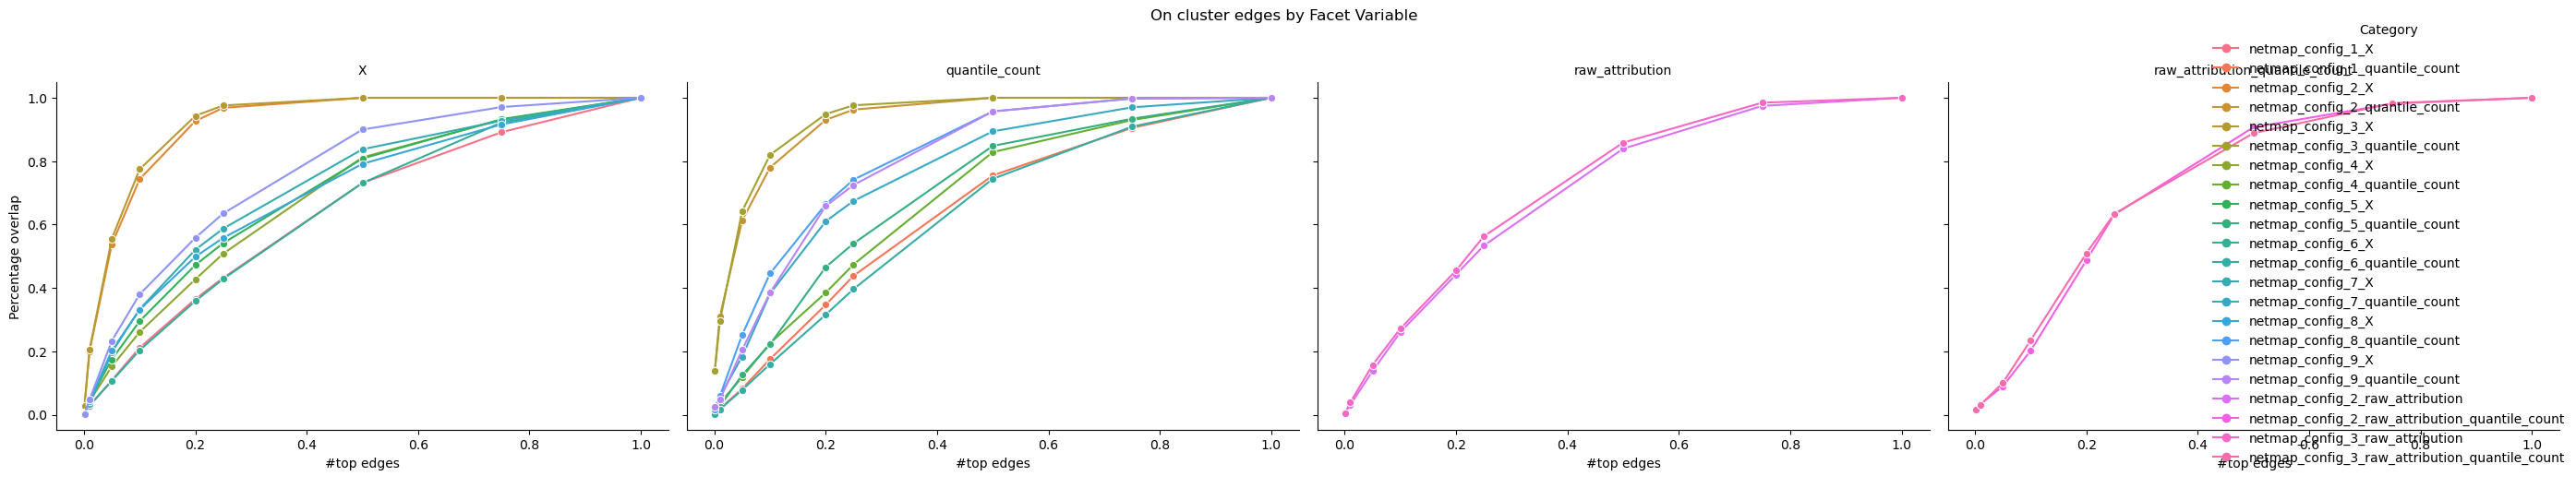

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'all_overlaps' is your DataFrame, and 'new_facet_variable' is the variable you want to use for faceting

# 1. Original data preprocessing (keep this)
all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
all_overlaps['percentage_overlap'] = all_overlaps['avg_edges_recovered']/all_overlaps['gold_standard_edges']

# 2. Filtering (keep this, or incorporate the filtering into the 'data' argument if using a DataFrame slice)
plot_data = all_overlaps[(all_overlaps.target == 'on_target') & (all_overlaps.net_type == 'strict') &  (all_overlaps.direction=='forward')]

# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=plot_data, # Use the filtered data
    x='n_top',
    y='percentage_overlap',
    hue='configuration', # The variable that separates lines within each panel
    col='layer', # 👈 THIS is the key change: creates a column for each unique value
    kind='line', # Specifies the type of plot (line plot)
    marker='o',
    errorbar=None, # Removes confidence intervals (optional, but consistent with your original note)
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
g.legend.set_title('Category') # Rename the legend title
plt.tight_layout()
plt.show()

In [16]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries', select=('overlaps_global_top_k_quantile_count.tsv'))
all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
all_overlaps['percentage_overlap'] = all_overlaps['avg_edges_recovered']/all_overlaps['gold_standard_edges']
all_overlaps['percentage_edges'] = all_overlaps['n_top']/all_overlaps['max_possible_edges']
all_overlaps =all_overlaps.sort_values('percentage_edges')




/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_55456_net_76_54079_net_51_55147/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_73_55226_net_105_55456_net_82_53921/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_63_54572_net_51_55200_net_94_55257/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_67_54752_net_142_54424_net_76_54079/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_64_55333_net_94_55257_net_53_54840/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_81_54174_net_191_54631_net_59_54965/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_76_54079_net_158_55084_net_164_54311/overlaps_global_top_k_quantile_count.tsv


In [ ]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries', select=('overlaps_global_top_k.tsv'))
all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
all_overlaps['percentage_overlap'] = all_overlaps['avg_edges_recovered']/all_overlaps['gold_standard_edges']

# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[(all_overlaps.target == 'on_target') & (all_overlaps.net_type == 'strict') &  (all_overlaps.direction=='forward')], x='n_top', y='percentage_overlap', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('On cluster edges')
plt.xlabel('#top edges')
plt.ylabel('Percentage overlap')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_70_1328_net_60_80_net_135_978/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_53_1113_net_70_1328_net_84_59925/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_59_459_net_115_1073_net_84_1140/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_172_585_net_89_1590_net_76_345/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_60_80_net_64_1212_net_84_1140/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_133_719_net_82_144_net_72_516/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_98_1873_net_51_844_net_60_80/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/result

AttributeError: 'DataFrame' object has no attribute 'avg_edges_recovered'

In [ ]:
import os
import os.path as op
import yaml
import pandas as pd

def read_all_results_yaml(root_dir, select = ('netmap_config_1.yaml')):
    """
    Reads all YAML files in a directory tree starting from root_dir, processes
    the nested structure, and concatenates the results into a single DataFrame.

    Args:
        root_dir (str): The path to the root directory.
        select (tuple or str): File extension or full filename to select.
                               Defaults to ('netmap_config_1.yaml').

    Returns:
        pandas.DataFrame: A DataFrame containing the processed data from all YAML files.
                          Returns an empty DataFrame if no files are found or an error occurs.
    """
    all_results_dfs = []

    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return pd.DataFrame() # Return an empty DataFrame

    if isinstance(select, str):
        select = (select,)

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            # Check if the filename ends with any of the selected strings/extensions
            if any(filename.endswith(s) for s in select):
                filepath = op.join(dirpath, filename)
                print(f"Processing: {filepath}")

                try:
                    with open(filepath, 'r') as f:
                        yaml_content = yaml.safe_load(f)

                    # Assuming the structure is:
                    # top_level_key:
                    #   net_key_1: {data}
                    #   net_key_2: {data}
                    #   other_metadata: value
                    
                    # We need to iterate over the nested networks, which are keys under the top-level key.
                    
                    if not yaml_content:
                        continue # Skip empty YAML file

                    # Get the top-level dictionary (e.g., netmap_config_1: {...})
                    top_key = list(yaml_content.keys())[0]
                    nested_data = yaml_content[top_key]
                    
                    records = []
                    # Extract the network-specific keys (like net_53_1113)
                    for key, data in nested_data.items():
                        print(key)
                        # Skip known non-network metadata fields
                        if key in ['clustering_score', 'total_number_edges']:
                            continue

                        # Create a record for the DataFrame
                        record = {'net_name': key, 'config_key': top_key, 'filename': filename}
                        record.update(data)
                        
                        # Add metadata from the nested_data if needed
                        if 'clustering_score' in nested_data:
                            record['clustering_score'] = nested_data['clustering_score']
                        if 'total_number_edges' in nested_data:
                            record['total_number_edges'] = nested_data['total_number_edges']
                            
                        records.append(record)

                    # Create a DataFrame from the extracted records
                    if records:
                        overlaps_df = pd.DataFrame(records)
                        # Add the directory name where the file was found (similar to your original 'net' column)
                        overlaps_df['net_directory'] = op.basename(op.dirname(filepath))
                        all_results_dfs.append(overlaps_df)

                except Exception as e:
                    print(f"Error reading or processing {filepath}: {e}")
                    continue

    if all_results_dfs:
        # Concatenate all DataFrames into one
        all_results = pd.concat(all_results_dfs, ignore_index=True)
    else:
        all_results = pd.DataFrame()

    return all_results

# Example Usage (assuming you have some YAML files to test with)
# results = read_all_results_yaml('/path/to/your/root_directory')
# print(results.head())

In [74]:
results = read_all_results_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries', select=('clustering_score.json'))


Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_70_1328_net_60_80_net_135_978/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_53_1113_net_70_1328_net_84_59925/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_59_459_net_115_1073_net_84_1140/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_172_585_net_89_1590_net_76_345/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_60_80_net_64_1212_net_84_1140/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_133_719_net_82_144_net_72_516/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_98_1873_net_51_844_net_60_80/clustering_score.json
P

In [75]:
results

,net_name,config_key,filename,edge_overlap,net_size,overlap_percent,reverse_overlap_percent,clustering_score,total_number_edges,net_directory
0,net_60_80,netmap_config_1,clustering_score.json,104,104,1.0,1.0,1.000000,70225,net_70_1328_net_60_80_net_135_978
1,net_70_1328,netmap_config_1,clustering_score.json,88,88,1.0,1.0,1.000000,70225,net_70_1328_net_60_80_net_135_978
2,net_53_1113,netmap_config_1,clustering_score.json,78,78,1.0,1.0,1.000000,42849,net_53_1113_net_70_1328_net_84_59925
3,net_70_1328,netmap_config_1,clustering_score.json,88,88,1.0,1.0,1.000000,42849,net_53_1113_net_70_1328_net_84_59925
4,net_115_1073,netmap_config_1,clustering_score.json,117,117,1.0,1.0,1.000000,66564,net_59_459_net_115_1073_net_84_1140
5,net_59_459,netmap_config_1,clustering_score.json,87,87,1.0,1.0,1.000000,66564,net_59_459_net_115_1073_net_84_1140
6,net_172_585,netmap_config_1,clustering_score.json,239,239,1.0,1.0,1.000000,113569,net_172_585_net_89_1590_net_76_345
7,net_89_1590,netmap_config_1,clustering_score.json,98,98,1.0,1.0,1.000000,113569,net_172_585_net_89_1590_net_76_345
8,net_60_80,netmap_config_2,clustering_score.json,104,104,1.0,1.0,1.000000,43264,net_60_80_net_64_1212_net_84_1140
9,net_64_1212,netmap_config_2,clustering_score.json,71,71,1.0,1.0,1.000000,43264,net_60_80_net_64_1212_net_84_1140


/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_55456_net_76_54079_net_51_55147/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_73_55226_net_105_55456_net_82_53921/overlaps_global_top_k_quantile_count.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_63_54572_net_51_55200_net_94_55257/overlaps_global_top_k_quantile_count.tsv


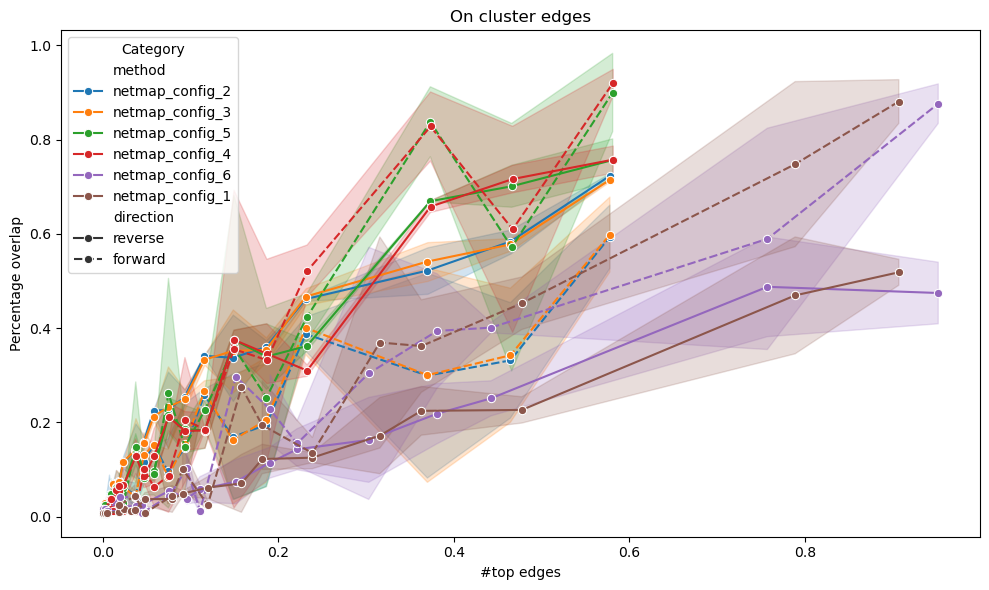

In [30]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries', select=('overlaps_global_top_k_quantile_count.tsv'))
#all_overlaps = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_55456_net_76_54079_net_51_55147/overlaps_global_top_k.tsv', sep= '\t')

all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
all_overlaps['percentage_overlap'] = all_overlaps['avg_edges_recovered']/all_overlaps['gold_standard_edges']
all_overlaps['percentage_edges'] = all_overlaps['n_top']/all_overlaps['max_possible_edges']
all_overlaps =all_overlaps.sort_values('percentage_edges')


# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[(all_overlaps.target == 'on_target') & (all_overlaps.net_type == 'strict') ], x='percentage_edges', y='percentage_overlap', hue='method', marker='o', style='direction')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('On cluster edges')
plt.xlabel('#top edges')
plt.ylabel('Percentage overlap')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

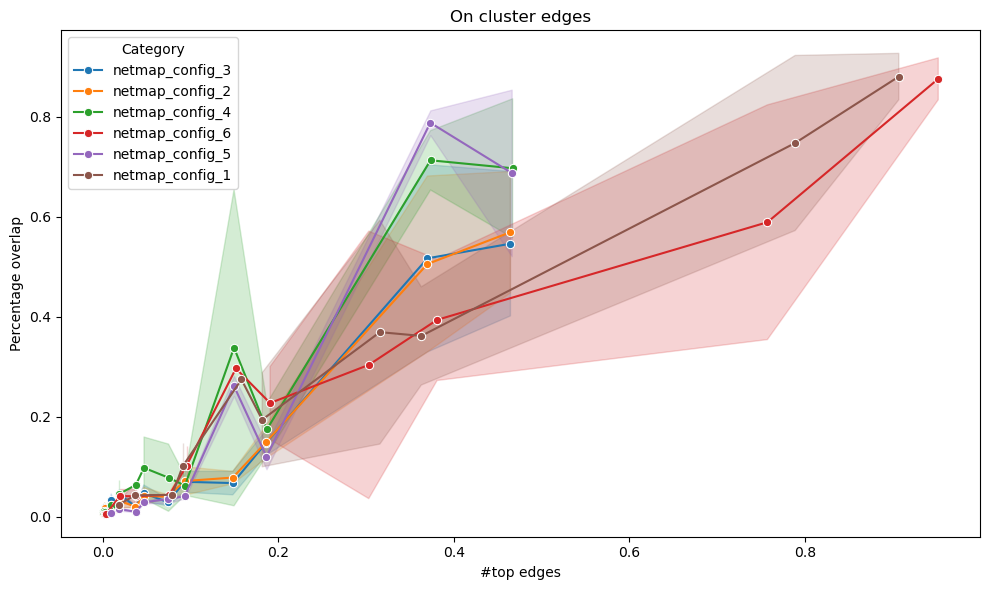

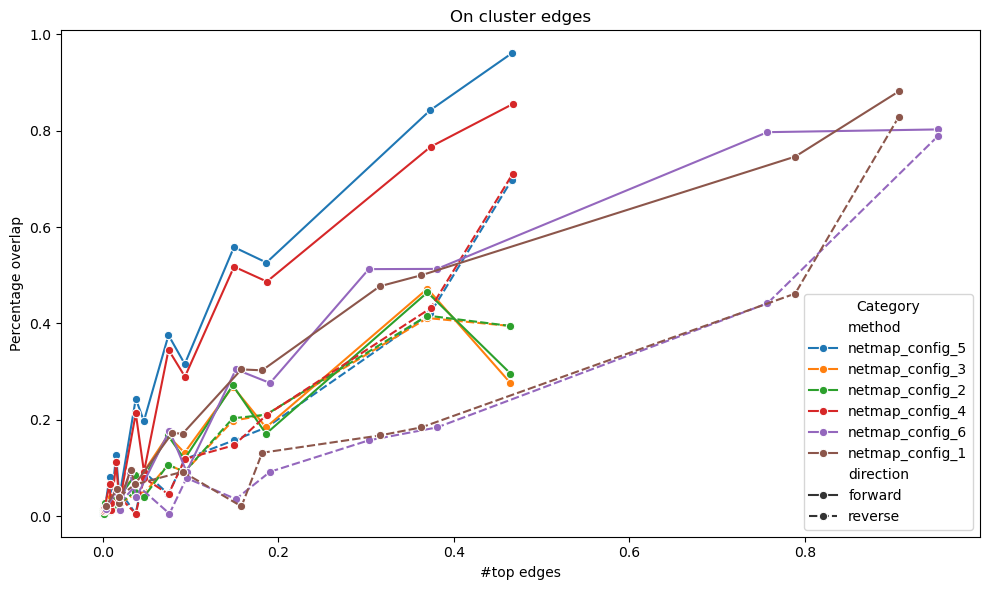

In [24]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[(all_overlaps.target == 'on_target') & (all_overlaps.net_type == 'unspecific')], x='percentage_edges', y='percentage_overlap', hue='method', marker='o', style='direction')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('On cluster edges')
plt.xlabel('#top edges')
plt.ylabel('Percentage overlap')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

In [58]:
all_overlaps[all_overlaps.method.isin(['grnboost2_config_2' ]) & (~all_overlaps.on_target.isna()) & (all_overlaps.n_top<50)]

AttributeError: 'DataFrame' object has no attribute 'on_target'

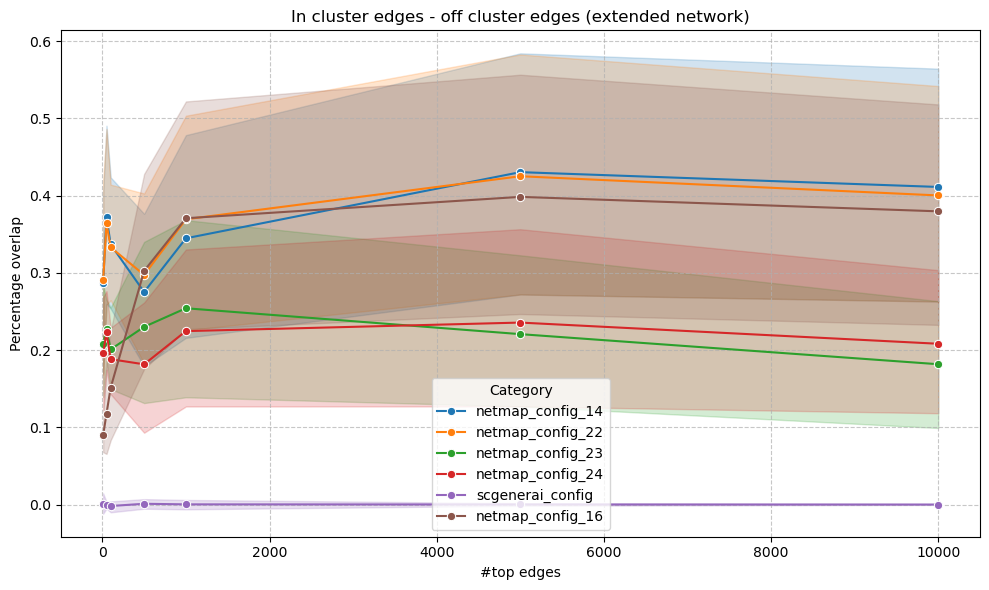

In [16]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[all_overlaps.method.isin(['netmap_config_14', 'netmap_config_16', 'netmap_config_22', 'netmap_config_23', 'netmap_config_24', 'scgenerai_config'])], x='n_top', y='difference_ot', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('In cluster edges - off cluster edges (extended network)')
plt.xlabel('#top edges')
plt.ylabel('Percentage overlap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

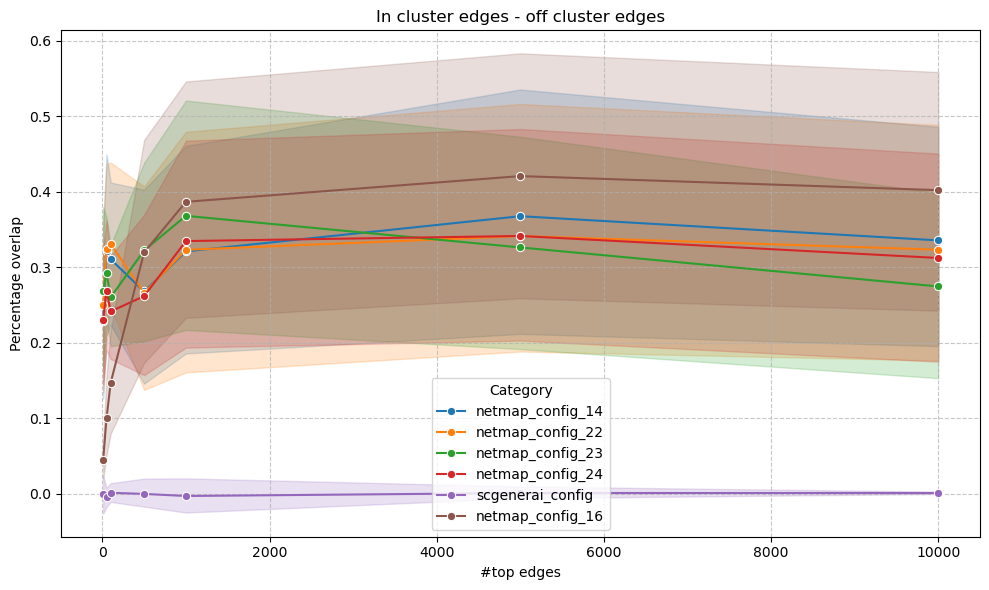

In [17]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[all_overlaps.method.isin(['netmap_config_14', 'netmap_config_16', 'netmap_config_22', 'netmap_config_23', 'netmap_config_24', 'scgenerai_config'])], x='n_top', y='difference', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('In cluster edges - off cluster edges')
plt.xlabel('#top edges')
plt.ylabel('Percentage overlap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

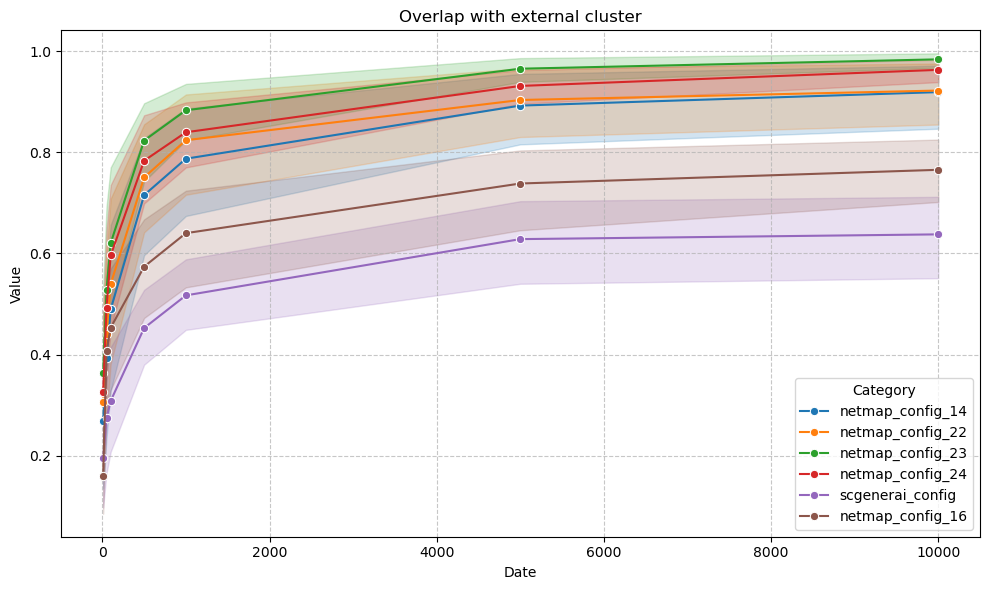

In [18]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[all_overlaps.method.isin(['netmap_config_14', 'netmap_config_16', 'netmap_config_22', 'netmap_config_23', 'netmap_config_24', 'scgenerai_config'])], x='n_top', y='external', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('Overlap with external cluster')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

In [19]:
all_overlaps

,Unnamed: 0,method,n_top,on_target,off_target,augmented_on,augmented_off,external,net,difference,difference_ot
0,0,netmap_config_10,10,0.090909,0.027273,0.078938,0.038527,0.013158,net_105_55456_net_76_54079_net_51_55147,0.063636,0.040411
1,1,netmap_config_10,10,0.098160,0.000000,0.100037,0.012597,0.039474,net_105_55456_net_76_54079_net_51_55147,0.098160,0.087440
2,2,netmap_config_10,50,0.345455,0.163636,0.225685,0.140240,0.157895,net_105_55456_net_76_54079_net_51_55147,0.181818,0.085445
3,3,netmap_config_10,50,0.202454,0.036810,0.237866,0.044461,0.276316,net_105_55456_net_76_54079_net_51_55147,0.165644,0.193405
4,4,netmap_config_10,100,0.445455,0.190909,0.318151,0.224315,0.328947,net_105_55456_net_76_54079_net_51_55147,0.254545,0.093836
...,...,...,...,...,...,...,...,...,...,...,...
51,23,grnboost2_config_2,100,0.954955,0.873874,NaN,NaN,NaN,net_149_54483_net_51_54813_net_59_54965,0.081081,NaN
52,24,grnboost2_config_2,11198,0.906593,NaN,NaN,NaN,NaN,net_149_54483_net_51_54813_net_59_54965,NaN,NaN
53,25,grnboost2_config_2,11198,NaN,0.873874,NaN,NaN,NaN,net_149_54483_net_51_54813_net_59_54965,NaN,NaN
54,26,grnboost2_config_2,11380,NaN,0.868132,NaN,NaN,NaN,net_149_54483_net_51_54813_net_59_54965,NaN,NaN


ValueError: cannot reindex on an axis with duplicate labels

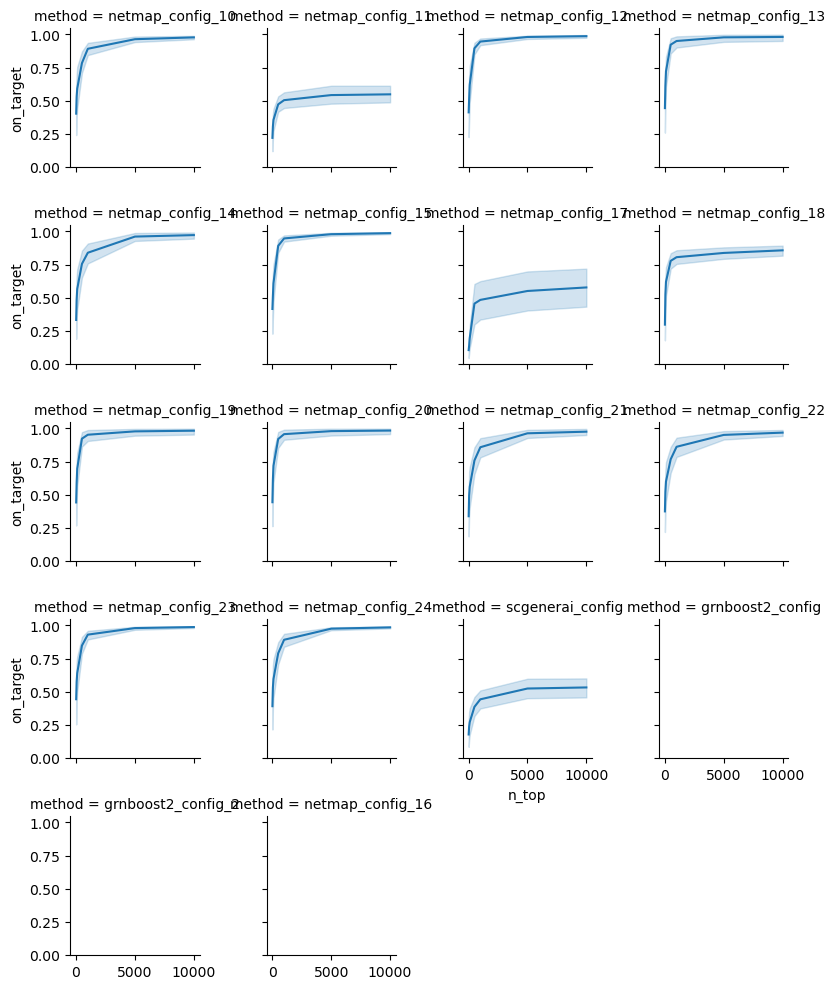

In [20]:

g = sns.FacetGrid(all_overlaps, col="method", col_wrap=4, height=2)
g.map(sns.lineplot, "n_top", "on_target")

ValueError: cannot reindex on an axis with duplicate labels

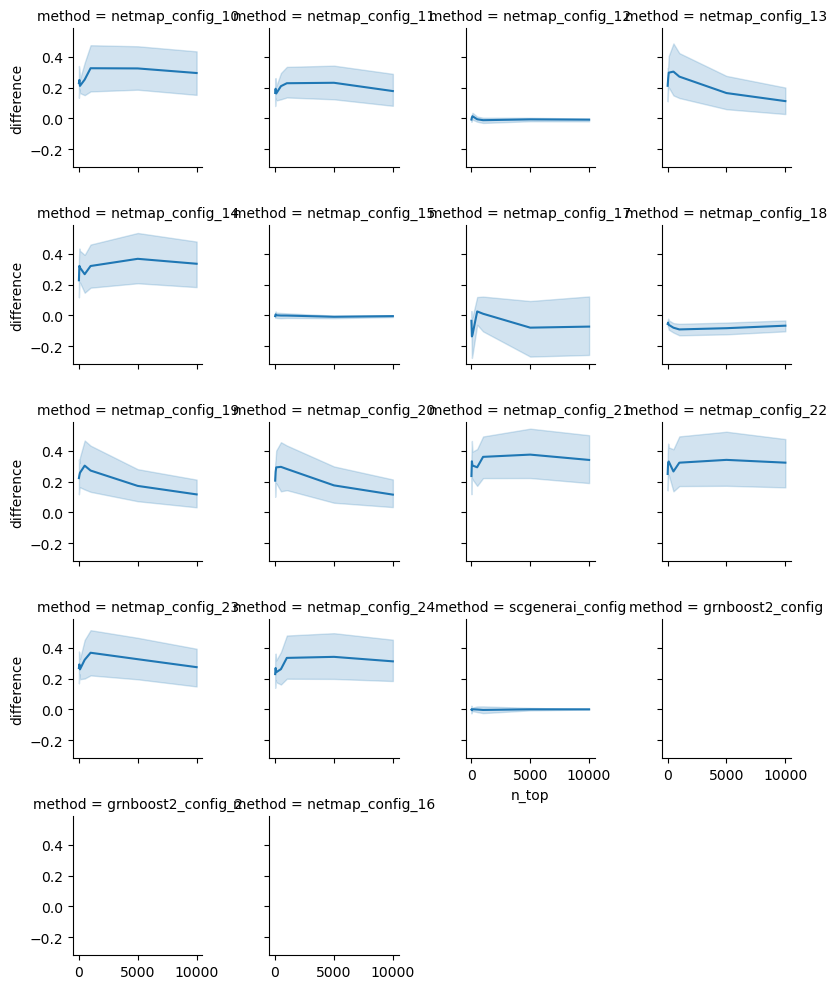

In [21]:

g = sns.FacetGrid(all_overlaps, col="method", col_wrap=4, height=2)
g.map(sns.lineplot, "n_top", "difference")

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='method', y='time_method_minutes', data=times)
sns.stripplot(x='method', y='time_method_minutes', data=times, color='black', size=5, jitter=True) # Adds individual points
plt.title('Wall times by Method')
plt.xlabel('Method')
plt.ylabel('Wall Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'times' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
import scanpy as sc

: 

: 

In [ ]:
import os
import yaml

def read_all_yaml_files(root_dir):
    """
    Reads all YAML files in a tree of directories starting from root_dir.

    Args:
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_yaml_data = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_yaml_data

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(('results.yaml', 'results.yml')):
                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as file:
                        yaml_data = yaml.safe_load(file)
                        if yaml_data is not None:  # Ensure the file wasn't empty
                            
                            yaml_data['net'] = op.basename(op.dirname(filepath))
                            yaml_data['config'] = op.basename(op.dirname(op.dirname(op.dirname(filepath))))
                            all_yaml_data.append(yaml_data)
                        else:
                            print(f"Warning: YAML file '{filepath}' is empty or contains no data.")
                        
                except yaml.YAMLError as exc:
                    print(f"Error parsing YAML file '{filepath}': {exc}")
                except Exception as e:
                    print(f"Error reading file '{filepath}': {e}")
    return all_yaml_data

: 

: 

In [ ]:
op.basename(op.dirname('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap'))

'results'

: 

: 

In [ ]:
all_times = read_all_yaml_files('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap')

: 

: 

In [ ]:
all_times = pd.DataFrame(all_times)

: 

: 

In [ ]:
all_times['tool_time'] = all_times['time_elapsed_netmap']/60

: 

: 

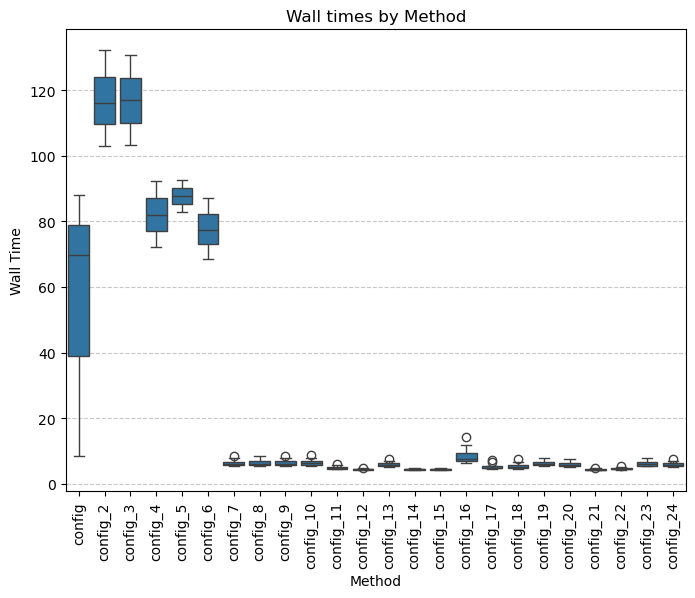

: 

: 

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='config', y='tool_time', data=all_times)
plt.title('Wall times by Method')
plt.xlabel('Method')
plt.ylabel('Wall Time')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import sys
import os.path as op
import os
sys.path.append('/data_nfs/og86asub/netmap/netmap-evaluation/')

import anndata
from netmap.src.utils.netmap_config import NetmapConfig
from src.methods.csnet.csnet_config import CsNetConfig
from src.methods.scgenerai.scgenerai_config import ScGeneRAIConfig
from src.data_simulation.data_simulation_config import DataSimulationConfig
from src.pipelines.utils import PipelineConfig
from captum.attr import GradientShap



import numpy as np
import scanpy as sc
import pandas as pd
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
import scipy.sparse as scs
from sklearn.cluster import SpectralClustering

from src.utils import write_config


def downstream_recipe(adata)-> anndata.AnnData:
    """
    Downstream reciepe for an LRP anndata object:
    TODO: replace the config dict, to pass values
    """
    config = {'min_cells':1, 'n_neighbors': 30, 'leiden_resolution': 0.1, 'n_components': 30, 'knn_neighbors': 30}
    sc.pp.filter_genes(adata, min_cells=config['min_cells'])
    #sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
    #sc.pp.normalize_total(adata)
    #sc.pp.log1p(adata)

    sc.tl.pca(adata, svd_solver = 'randomized', zero_center = False)

    sc.pp.neighbors(adata, n_neighbors=config['knn_neighbors'])
    sc.tl.leiden(adata, resolution=config['leiden_resolution'])

    sc.tl.umap(adata, n_components = config['n_components'])
    return adata


def spectral_clustering(adata, n_clu = 2, key_added = 'spectral'):
    """
    Run sklearn spectral clustering on the neighbour matrix in the anndata object.

    Args:
    adata: Anndata object
    n_clu: Number of clusters to compute
    key_added: The key to add the new labelling to [Default: spectral]
    """
    sc.pp.neighbors(adata)
    ssc = SpectralClustering(n_clusters=n_clu,assign_labels='discretize',random_state=0, affinity= 'precomputed_nearest_neighbors').fit(adata.obsp['distances'])
    counter = 0
    key_added_t = key_added
    while key_added_t in adata.obs.columns:
        counter = counter + 1
        key_added_t = f'{key_added}_{counter}'
    adata.obs[key_added_t] = ssc.labels_
    adata.obs[key_added_t] = pd.Categorical(adata.obs[key_added_t])
    return adata


def unify_group_labelling(adata, grn_adata, col_adata, col_grn_adata, return_mapping=False):
    """
    Adjust group labelling such that grn_adata has the same group label than the 
    corresponding column in adata based on the grn column.

    Returns the data objects and a score of the matching as the cost of the matching
    divided by the number of cells.
    
    """

    cm = contingency_matrix(adata.obs[col_adata], grn_adata.obs[col_grn_adata])
    row_ind, col_ind = linear_sum_assignment(cm, maximize = True)
    
    names_ad = np.unique(adata.obs[col_adata])
    print(names_ad)
    names_grn = np.unique(grn_adata.obs[col_grn_adata])
    mapping = {}
    reverse_mapping = {}
    for i in range(len(row_ind)):
        reverse_mapping[names_grn[col_ind[i]]] = names_ad[row_ind[i]]

    col_grn_adata_remapped = col_grn_adata + '_remap'
    if isinstance(np.unique(grn_adata.obs[col_grn_adata])[0], str):
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[a] for a in grn_adata.obs[col_grn_adata]]
    else:
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[int(a)] for a in grn_adata.obs[col_grn_adata]]

    grn_adata.obs[col_grn_adata_remapped] = pd.Categorical(grn_adata.obs[col_grn_adata_remapped])

    score = cm[row_ind, col_ind].sum()/adata.obs.shape[0]
    if return_mapping:
        return adata, grn_adata, score, reverse_mapping
    else:
        return adata, grn_adata, score

def compute_egde_overlaps_simple(grn_adata, net_list):
    print(grn_adata.var.columns)
    net_recovery = {}
    for net_name, net in net_list:
        print(net_name)
        print(net)
        print(grn_adata.var)
        overlap_count = (pd.merge(grn_adata.var, net, on=['source', 'target'], how='inner').shape[0])
        print(overlap_count)
        reverse_overlap = (pd.merge(grn_adata.var, net, on=['target', 'source'], how='inner').shape[0])
        net_size = net.shape[0]
        overlap_perc = overlap_count/net_size
        reverse_overlap_perc = reverse_overlap/net_size
        net_recovery[net_name] = {'edge_overlap':overlap_count, 'net_size': net_size, 'overlap_percent':overlap_perc, 'reverse_overlap_percent': reverse_overlap_perc}

        net_recovery['total_number_edges'] = grn_adata.var.shape[0]
    return net_recovery



def process(grn_adata):
    if not scs.issparse(grn_adata.X):
        grn_adata.X[np.isnan(grn_adata.X) ] = 0
    grn_adata = downstream_recipe(grn_adata)
    grn_adata = spectral_clustering(grn_adata)
    return grn_adata

def get_top_edges_per_cell(grn_adata, top_edges):
    

    b = np.argpartition(grn_adata.X, top_edges)    # top 3 values from each row
    top_idx = b[:,-top_edges:]

    print(grn_adata.var.columns)
    scgenerai_var_index_np = np.array(grn_adata.var)
    top_edges_per_cell = pd.DataFrame(np.concat(scgenerai_var_index_np[top_idx]))
    top_edges_per_cell.columns = ['source', 'target', 'n_cells']
    top_edges_per_cell['cell_barcode'] = np.repeat(grn_adata.obs.index, repeats=top_edges)
    return top_edges_per_cell



def get_top_edges_per_cell_per_cluster(grn_adata, nets, cluster_var = 'spectral_remap', top_edges=5000):
    
    grns = grn_adata.obs[cluster_var].unique()
    on_target = []
    off_target = []
    # Correct cluster :)
    for i in range(len(nets)):
        for j in range(len(grns)):
            clu = grns[j]
            grn = nets[i]
            print(clu)
            print(f"Cluster {clu} -- GRN {grn[0]}")

            grn_adata_sub = grn_adata[grn_adata.obs[cluster_var] == clu]
            # identify the genes with the highest mean
            top_edges_per_cell = get_top_edges_per_cell(grn_adata_sub,  top_edges)
            agg = top_edges_per_cell.merge(grn[1], left_on=['source', 'target'], right_on = ['source', 'target']).loc[:,['source', 'target']].groupby(['source', 'target']).value_counts()
            agg = agg.reset_index()
            
            if i == j:
                on_target.append(agg.shape[0]/grn[1].shape[0])
            else: 
                off_target.append(agg.shape[0]/grn[1].shape[0])
    return on_target, off_target


def build_augmented_network(net):
    """
    Insert an edge between two genes if they are regulated by the same gene.
    """
    augmented_net = []
    for s in net.source.unique():
        targets = net[net.source == s].target.unique()
        cro = np.transpose([np.tile(targets, len(targets)), np.repeat(targets, len(targets))])
        augmented_net.append(cro)
    augmented_net = pd.DataFrame(np.vstack(augmented_net))
    augmented_net.columns = ['source', 'target']
    augmented_net['edge' ] = augmented_net['source']+'_'+augmented_net['target']
    return augmented_net


def compute_metrics(grn_ads, nets, group_key='grn'):
    collect_results = {}
    for method in grn_ads:
        print(method)
        try:
            try:
                collect_results[method] = compute_egde_overlaps_simple(grn_ads[method], nets)
            
                grn_ads[method] = process(grn_ads[method])
                grn_ads[method], grn_ads[method], score = unify_group_labelling(grn_ads[method], grn_ads[method], group_key, 'spectral')
                collect_results[method]['clustering_score'] = float(score)
                try:
                    print('top 100')
                    ont, oft = get_top_edges_per_cell_per_cluster(grn_ads[method], nets, cluster_var = 'spectral_remap', top_edges=500)
                    collect_results[method]['on_grn_overlap'] = ont
                    collect_results[method]['off_grn_overlap'] = oft
                except:
                    print('error')
            except KeyError:
                print('empty anndata')

        except FileNotFoundError:
            collect_results[method] = 'no data'
    return collect_results



In [ ]:
dataset_config = DataSimulationConfig.read_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/configurations/data_simulation/config_easy/net_172_13576_net_131_13677_net_158_13767.config.yaml')
pipeline_config = PipelineConfig.read_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/configurations/pipelines/pipeline_config.yaml')


    # read network files
    
nets = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.edgelist]
off_net = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.common_edges]

baseadata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/simulated_data/config_easy/net_172_13576_net_131_13677_net_158_13767//data.h5ad')
data_14 = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_14/config_easy/net_172_13576_net_131_13677_net_158_13767//grn_lrp.h5ad')
data_23 = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_23/config_easy/net_172_13576_net_131_13677_net_158_13767/grn_lrp.h5ad')

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
data_18 = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_18/config_easy/net_172_13576_net_131_13677_net_158_13767/grn_lrp.h5ad')

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
data_22 = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_22/config_easy/net_172_13576_net_131_13677_net_158_13767/grn_lrp.h5ad')

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
ad1 = process(data_22)
ad1,ad1, score = unify_group_labelling(ad1, ad1, 'grn', 'spectral')

ad2 = process(data_14)
ad2,ad2, score = unify_group_labelling(ad2, ad2, 'grn', 'spectral')

/tmp/ipykernel_255288/1744959742.py:41: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=config['leiden_resolution'])
/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1. 2.]
[1. 2.]


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
ad2 = process(data_18)
ad2,ad2, score = unify_group_labelling(ad2, ad2, 'grn', 'spectral')

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


[1. 2.]


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
ad3 = process(data_23)
ad3,ad3, score = unify_group_labelling(ad3, ad3, 'grn', 'spectral')

[1. 2.]


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:

def compute_metrics(ad1, ad2, nets, group_key='grn', top_edges = 100):
    collect_results = {}

            
 
    cluster_var = 'spectral'
    grns = ad1.obs[ 'spectral'].unique()
    on_target = []
    off_target = []
    # Correct cluster :)
    for i in range(len(nets)):
        for j in range(len(grns)):
            clu = grns[j]
            grn = nets[i]
            print(clu)
            print(f"Cluster {clu} -- GRN {grn[0]}")

            grn_adata_sub = ad1[ad1.obs[cluster_var] == clu]
            # identify the genes with the highest mean
            top_edges_per_cell = get_top_edges_per_cell(grn_adata_sub,  top_edges)
            agg = top_edges_per_cell.merge(grn[1], left_on=['source', 'target'], right_on = ['source', 'target']).loc[:,['source', 'target']].groupby(['source', 'target']).value_counts()
            agg = agg.reset_index()

            grn_adata_sub2 = ad2[ad2.obs[cluster_var] == clu]
            # identify the genes with the highest mean
            top_edges_per_cell2 = get_top_edges_per_cell(grn_adata_sub2,  top_edges)
            agg2 = top_edges_per_cell.merge(grn[1], left_on=['source', 'target'], right_on = ['source', 'target']).loc[:,['source', 'target']].groupby(['source', 'target']).value_counts()
            agg2 = agg.reset_index()

            print(agg.shape)
            print(agg2.shape)
            print(agg.merge(agg2, left_on=['source', 'target'], right_on = ['source', 'target']).loc[:,['source', 'target']].groupby(['source', 'target']).value_counts().reset_index().shape)

            
            if i == j:
                on_target.append(agg.shape[0]/grn[1].shape[0])
            else: 
                off_target.append(agg.shape[0]/grn[1].shape[0])
    return on_target, off_target


In [ ]:

   
compute_metrics(ad1, ad2, nets, top_edges=1000)

0
Cluster 0 -- GRN net_172_13576
Index(['source', 'target', 'n_cells'], dtype='object')
Index(['source', 'target', 'n_cells'], dtype='object')
(6, 3)
(6, 4)
(6, 3)
1
Cluster 1 -- GRN net_172_13576
Index(['source', 'target', 'n_cells'], dtype='object')
Index(['source', 'target', 'n_cells'], dtype='object')
(6, 3)
(6, 4)
(6, 3)
0
Cluster 0 -- GRN net_131_13677
Index(['source', 'target', 'n_cells'], dtype='object')
Index(['source', 'target', 'n_cells'], dtype='object')
(1, 3)
(1, 4)
(1, 3)
1
Cluster 1 -- GRN net_131_13677
Index(['source', 'target', 'n_cells'], dtype='object')
Index(['source', 'target', 'n_cells'], dtype='object')
(3, 3)
(3, 4)
(3, 3)


([0.01875, 0.02158273381294964], [0.01875, 0.007194244604316547])

In [ ]:
nets


[('net_172_13576',
         source  target
  0       PPARG   PPARA
  1       PPARG   ESRRA
  2       PPARG   NCOR2
  3       PPARG   PPARD
  4       PPARG     CIC
  ..        ...     ...
  315     NRIP1  SLC7A1
  316     KDM3B    UCP1
  317  PPARGC1B    UCP2
  318  PPARGC1B    MTTP
  319  PPARGC1B   SYTL4
  
  [320 rows x 2 columns]),
 ('net_131_13677',
       source   target
  0     NR2C2       AR
  1     NR2C2  TGFB1I1
  2     NR2C2     ELK4
  3     NR2C2      DR1
  4     NR2C2   MAP2K7
  ..      ...      ...
  134  HOXC11      LCT
  135  HOXC11    S100B
  136  ZNF513     ARR3
  137    PAWR   DIABLO
  138    PAWR     CCN3
  
  [139 rows x 2 columns])]

In [ ]:
off_net

[('net_158_13767',
        source  target
  0      NR0B2   NR1H4
  1      NR0B2   NR5A2
  2      NR0B2   NR1H3
  3      NR0B2   NCOA1
  4      NR0B2   FOXM1
  ..       ...     ...
  394  CREB3L3   FGF21
  395  CREB3L3    PCK2
  396   ZBTB7C    FASN
  397    NCOA6  CYP3A4
  398    NCOA6  CYP2C9
  
  [399 rows x 2 columns])]

In [ ]:
np.where(data_14.var_names == 'AR_ABCB11')

(array([1892]),)

In [ ]:
off_net[0][1][off_net[0][1].target == 'AATF']

,source,target


In [ ]:
nets[1][1][nets[1][1].target == 'AR']

,source,target,edge
0,NR2C2,AR,NR2C2_AR


In [ ]:
nets[1][1][nets[1][1].source == 'AR']

,source,target
7,AR,TGFB1I1
8,AR,ELK4
9,AR,NCOA2
10,AR,URI1
11,AR,SRCAP
...,...,...
115,AR,NPEPPS
116,AR,PTPN9
117,AR,PTPRM
118,AR,SUSD6


In [ ]:
np.where(data_14.var_names == 'NR2C2_AR')


(array([24195]),)

In [ ]:
nets

[('net_172_13576',
         source  target            edge
  0       PPARG   PPARA     PPARG_PPARA
  1       PPARG   ESRRA     PPARG_ESRRA
  2       PPARG   NCOR2     PPARG_NCOR2
  3       PPARG   PPARD     PPARG_PPARD
  4       PPARG     CIC       PPARG_CIC
  ..        ...     ...             ...
  315     NRIP1  SLC7A1    NRIP1_SLC7A1
  316     KDM3B    UCP1      KDM3B_UCP1
  317  PPARGC1B    UCP2   PPARGC1B_UCP2
  318  PPARGC1B    MTTP   PPARGC1B_MTTP
  319  PPARGC1B   SYTL4  PPARGC1B_SYTL4
  
  [320 rows x 3 columns]),
 ('net_131_13677',
       source   target           edge
  0     NR2C2       AR       NR2C2_AR
  1     NR2C2  TGFB1I1  NR2C2_TGFB1I1
  2     NR2C2     ELK4     NR2C2_ELK4
  3     NR2C2      DR1      NR2C2_DR1
  4     NR2C2   MAP2K7   NR2C2_MAP2K7
  ..      ...      ...            ...
  134  HOXC11      LCT     HOXC11_LCT
  135  HOXC11    S100B   HOXC11_S100B
  136  ZNF513     ARR3    ZNF513_ARR3
  137    PAWR   DIABLO    PAWR_DIABLO
  138    PAWR     CCN3      PAWR_C

In [ ]:
nets[1][1][nets[1][1].target == 'AR']
nets[1][1][nets[1][1].source == 'NR2C2']
nets[1][1][nets[1][1].source == 'AR']
nets[1][1][nets[0][1].source == 'ABCB1']



/tmp/ipykernel_255288/1483171461.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nets[1][1][nets[0][1].source == 'ABCB1']


,source,target,edge


In [ ]:
nets1 = nets[1][1]
nets0 = nets[0][1]

In [ ]:
nets1[nets1.source =='HOXC11']

,source,target,edge
133,HOXC11,PAWR,HOXC11_PAWR
134,HOXC11,LCT,HOXC11_LCT
135,HOXC11,S100B,HOXC11_S100B


In [ ]:
nets1['edge'] = nets1['source']+'_'+ nets1['target']
nets0['edge'] = nets0['source']+'_'+ nets0['target']

In [ ]:
np.sort(nets1[nets1.source == 'HOXC11'].edge)

array(['HOXC11_LCT', 'HOXC11_PAWR', 'HOXC11_S100B'], dtype=object)

In [ ]:
nets0[nets0.source == 'ZNF746']

,source,target,edge
312,ZNF746,PCK1,ZNF746_PCK1


In [ ]:
nets0[nets0.target == 'PCK1']

,source,target,edge
7,PPARG,PCK1,PPARG_PCK1
98,PPARA,PCK1,PPARA_PCK1
182,NR2F1,PCK1,NR2F1_PCK1
203,NR0B1,PCK1,NR0B1_PCK1
210,ESRRA,PCK1,ESRRA_PCK1
228,NCOR2,PCK1,NCOR2_PCK1
238,RXRA,PCK1,RXRA_PCK1
265,PPARD,PCK1,PPARD_PCK1
302,ESRRG,PCK1,ESRRG_PCK1
312,ZNF746,PCK1,ZNF746_PCK1


In [ ]:
baseadata.obs['grn'] = pd.Categorical(baseadata.obs['grn'] )

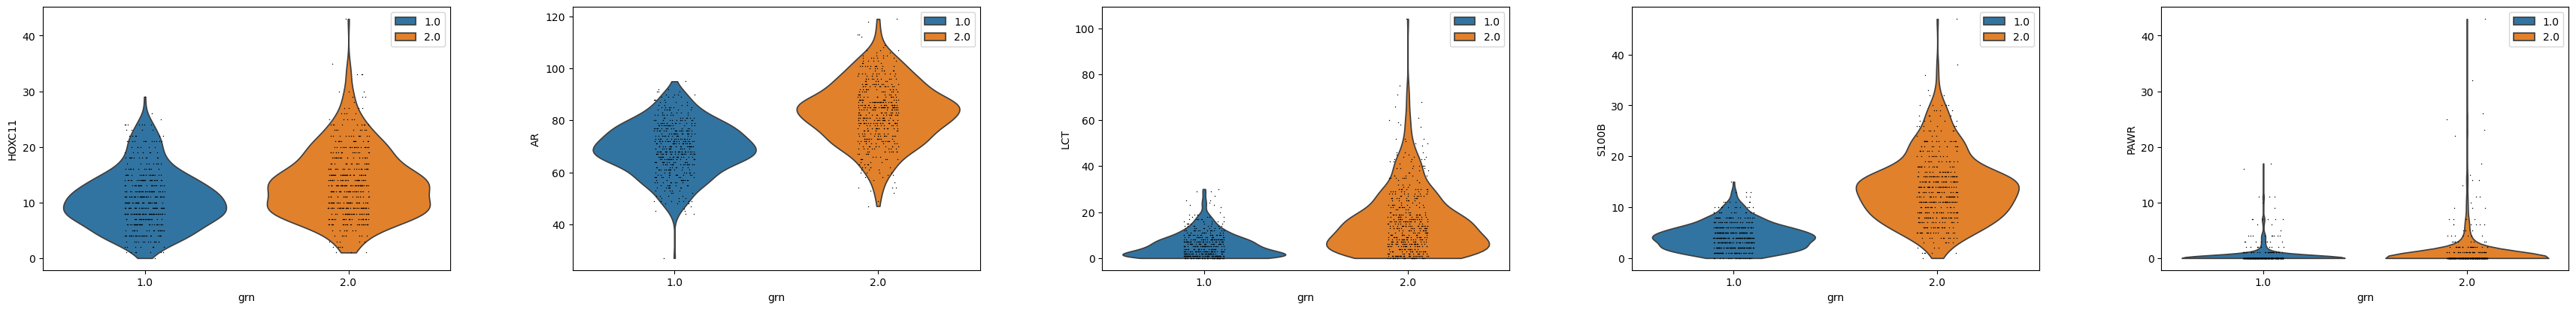

In [ ]:
sc.pl.violin(baseadata, keys = ['HOXC11', 'AR', 'LCT', 'S100B', 'PAWR'], groupby='grn')

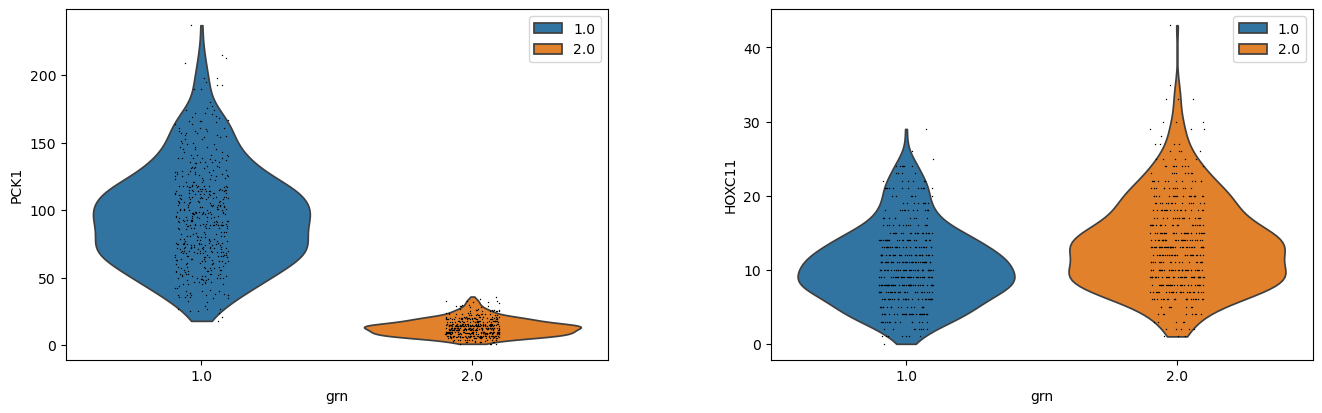

In [ ]:
sc.pl.violin(baseadata, keys = ['PCK1', 'HOXC11'], groupby='grn')

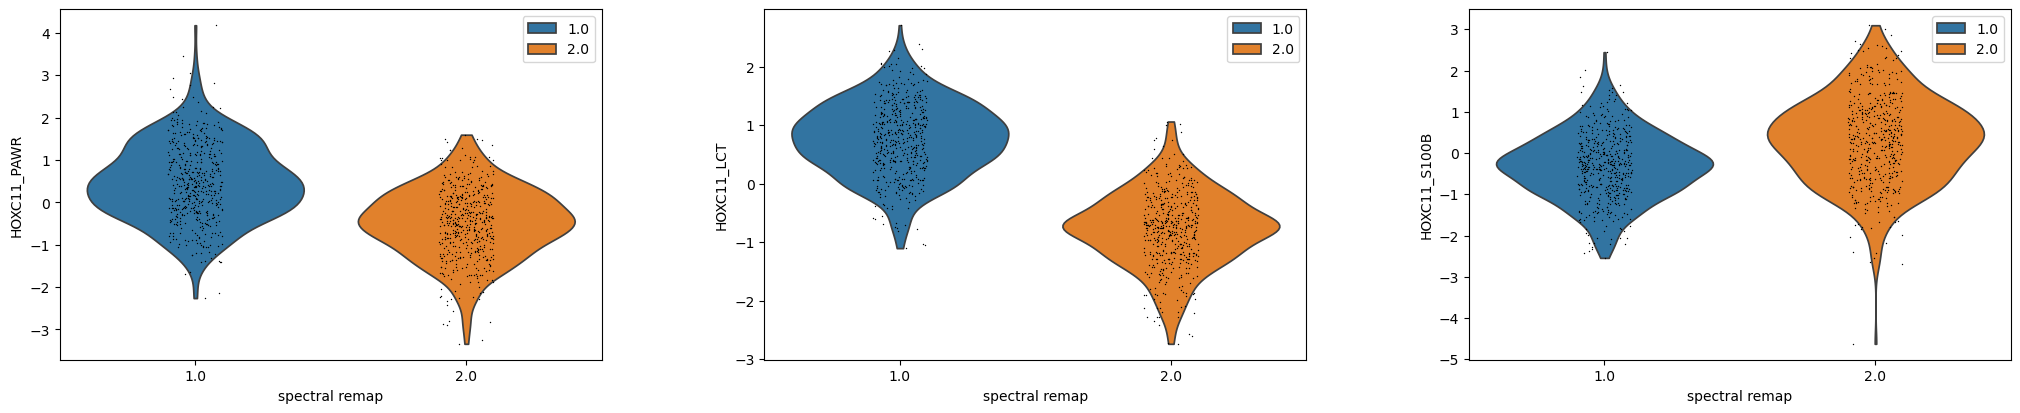

: 

: 

In [ ]:
sc.pl.violin(data_14, keys = nets1[nets1.source =='HOXC11'].edge, groupby='spectral_remap', use_raw=False)

In [ ]:
data_14.obs['grn']  = pd.Categorical(data_14.obs['grn'] )

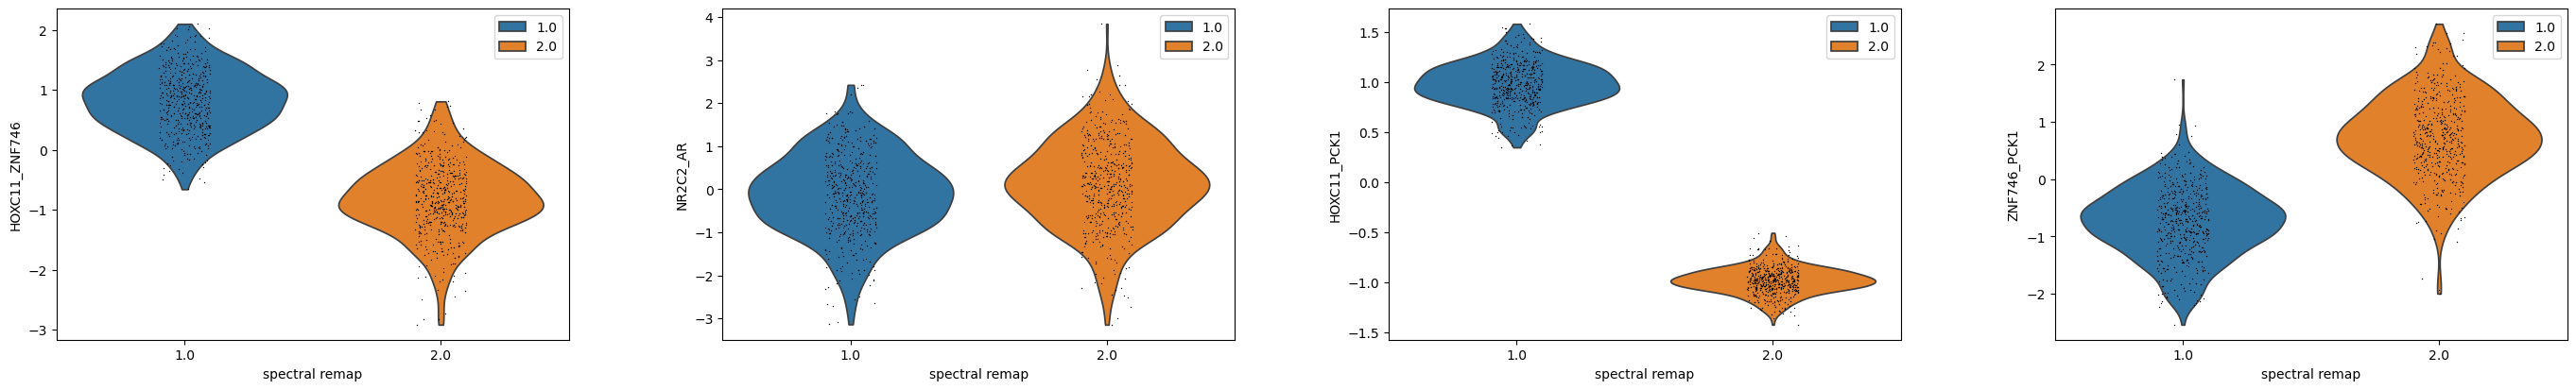

In [ ]:
sc.pl.violin(data_14, keys = ['HOXC11_ZNF746', 'NR2C2_AR', 'HOXC11_PCK1', 'ZNF746_PCK1'], groupby='spectral_remap', use_raw=False)

In [ ]:

print(grn_adata.var.columns)
net_recovery = {}
for net_name, net in net_list:
    print(net_name)
    print(net.source.unique())
    print(grn_adata.var)
    overlap_count = (pd.merge(grn_adata.var, net, on=['source', 'target'], how='inner').shape[0])
    print(overlap_count)
    reverse_overlap = (pd.merge(grn_adata.var, net, on=['target', 'source'], how='inner').shape[0])
    net_size = net.shape[0]
    overlap_perc = overlap_count/net_size
    reverse_overlap_perc = reverse_overlap/net_size
    net_recovery[net_name] = {'edge_overlap':overlap_count, 'net_size': net_size, 'overlap_percent':overlap_perc, 'reverse_overlap_percent': reverse_overlap_perc}

    net_recovery['total_number_edges'] = grn_adata.var.shape[0]



Index(['index', 'source', 'target'], dtype='object')
net_63_13257
['ZNF281' 'ZEB1' 'SNAI1' 'TWIST1' 'HOXA7' 'TWIST2' 'SNAI2' 'ZEB2' 'KLF8'
 'ZNF77' 'MEIS2' 'SATB2' 'ZKSCAN3' 'GRHL2' 'KLF17']
                 index   source   target
0         ACAN_ZNF804A     ACAN     ACAN
1          ACE_ZNF804A      ACE     ACAN
2       ADARB1_ZNF804A   ADARB1     ACAN
3        ADSS1_ZNF804A    ADSS1     ACAN
4       AKAP8L_ZNF804A   AKAP8L     ACAN
...                ...      ...      ...
43259   ZNF268_ZNF804A   ZNF268  ZNF804A
43260   ZNF281_ZNF804A   ZNF281  ZNF804A
43261   ZNF750_ZNF804A   ZNF750  ZNF804A
43262    ZNF77_ZNF804A    ZNF77  ZNF804A
43263  ZNF804A_ZNF804A  ZNF804A  ZNF804A

[43264 rows x 3 columns]
131
net_51_13886
['CARF' 'NR3C2' 'TFCP2' 'SRY' 'CXXC1' 'SOX11' 'MECP2' 'CREB3L2']
                 index   source   target
0         ACAN_ZNF804A     ACAN     ACAN
1          ACE_ZNF804A      ACE     ACAN
2       ADARB1_ZNF804A   ADARB1     ACAN
3        ADSS1_ZNF804A    ADSS1     ACAN
4   

: 

: 